# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:

# Coba load dari sklearn, fallback ke CSV
try:
    from sklearn.datasets import fetch_california_housing
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame
    print("Loaded from sklearn")
except Exception:
    df = pd.read_csv("../housing_raw.csv")
    print("Loaded from CSV")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Loaded from sklearn
Dataset shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Load California Housing Dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Simpan raw dataset
df.to_csv('../housing_raw.csv', index=False)
print('Raw dataset saved to housing_raw.csv')

Raw dataset saved to housing_raw.csv


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# Basic info
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
# Statistik deskriptif
print('=== Descriptive Statistics ===')
df.describe()

=== Descriptive Statistics ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
# Cek missing values
print('=== Missing Values ===')
print(df.isnull().sum())
print('\nTotal missing:', df.isnull().sum().sum())

=== Missing Values ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing: 0


In [8]:
# Cek duplikat
print('=== Duplicate Rows ===')
print('Total duplicates:', df.duplicated().sum())

=== Duplicate Rows ===
Total duplicates: 0


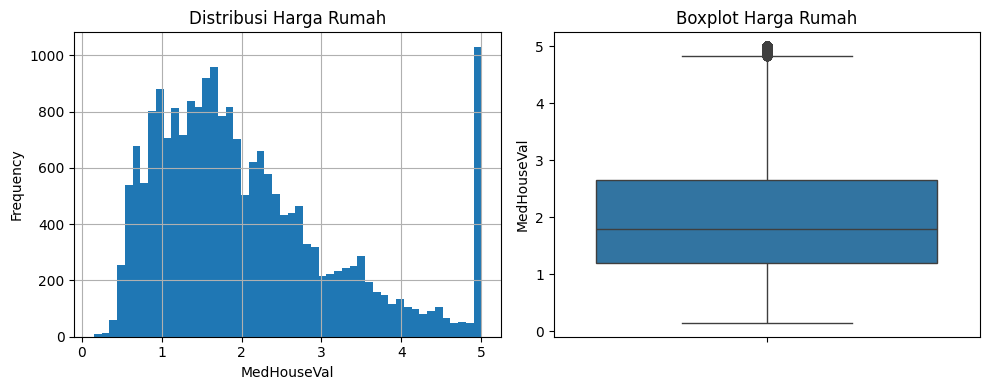

Plot saved


In [9]:


# Distribusi target variable
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['MedHouseVal'].hist(bins=50)
plt.title('Distribusi Harga Rumah')
plt.xlabel('MedHouseVal')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['MedHouseVal'])
plt.title('Boxplot Harga Rumah')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot saved')

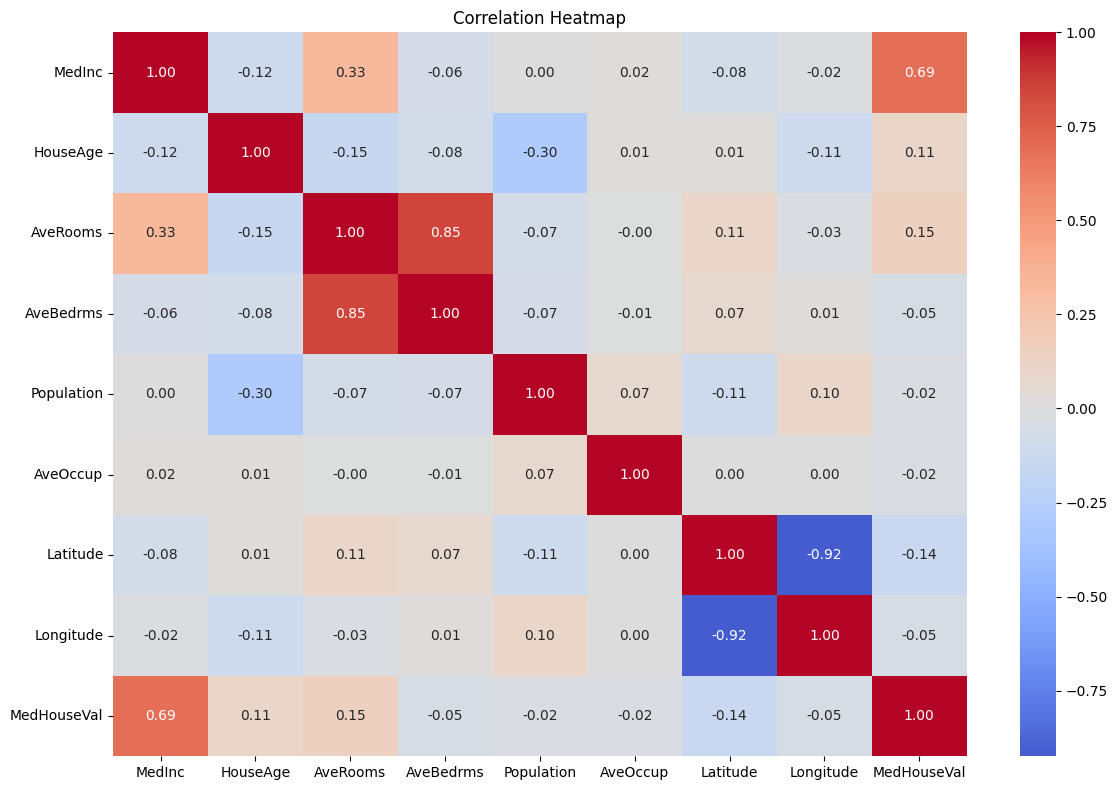

In [10]:
# Korelasi antar fitur
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

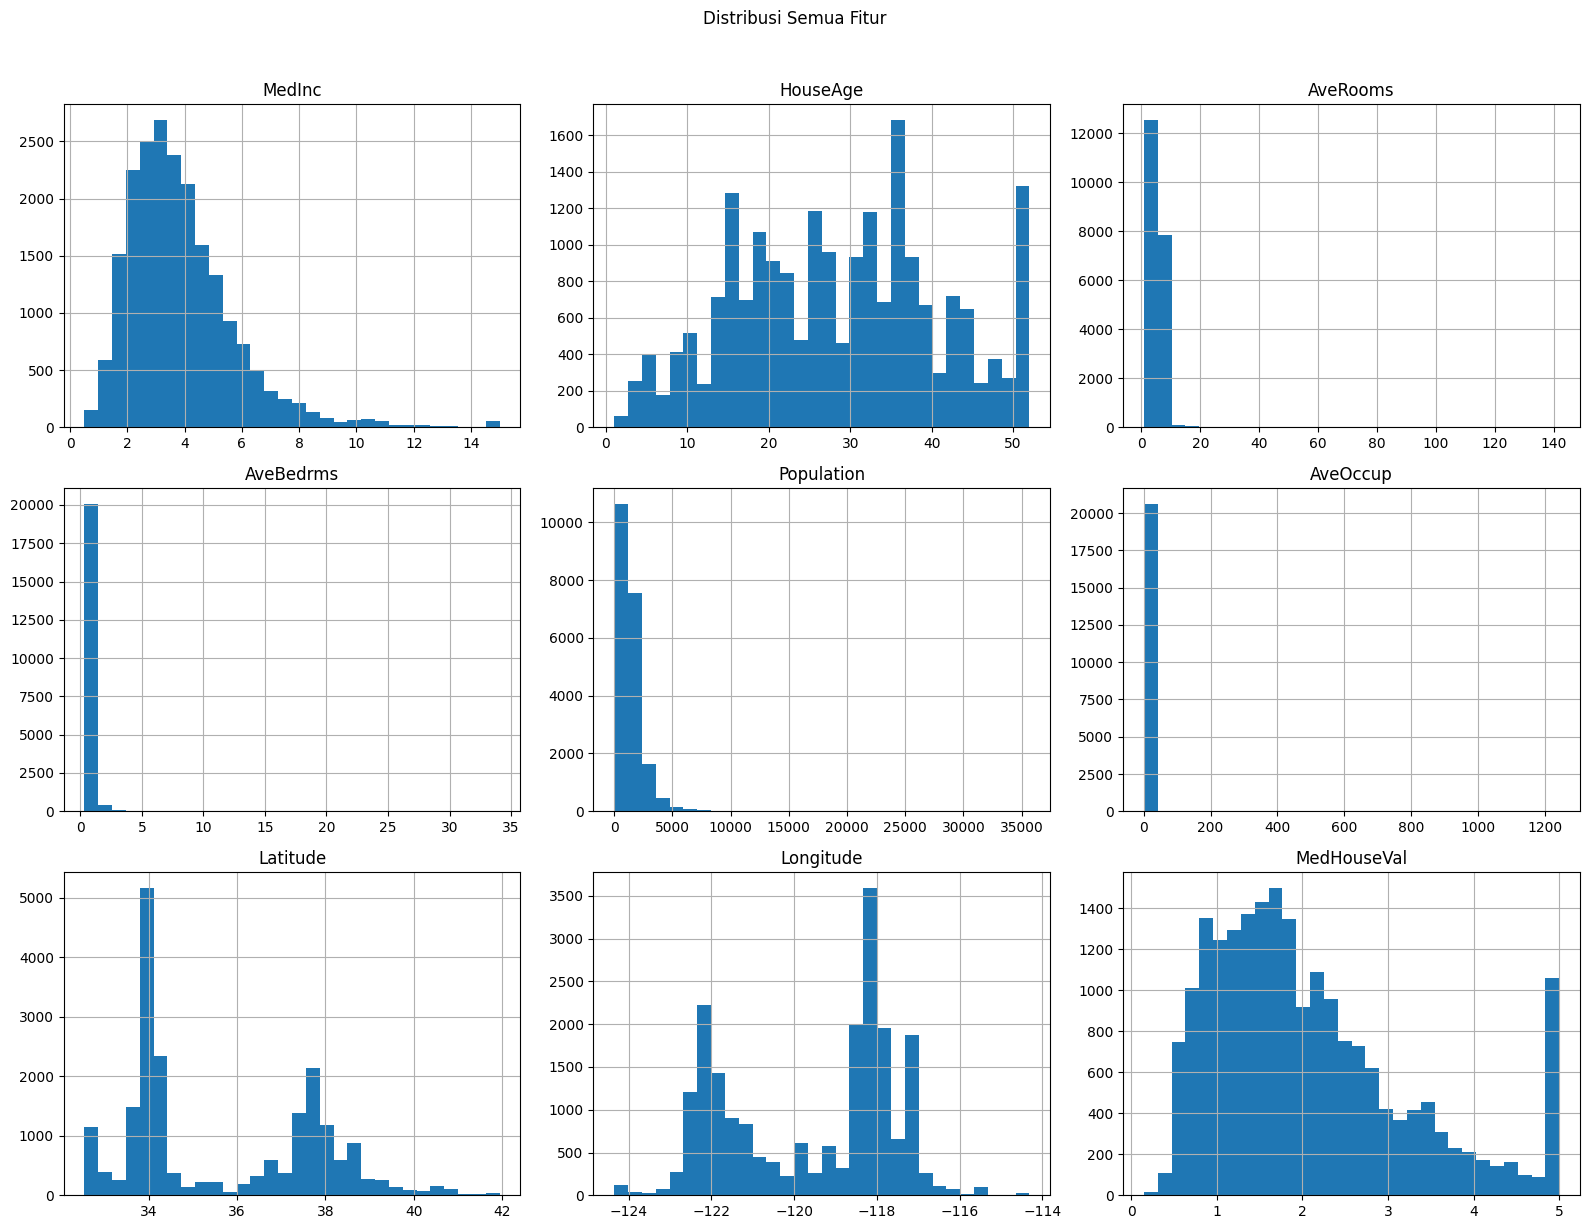

In [11]:
# Distribusi semua fitur
df.hist(figsize=(16, 12), bins=30)
plt.suptitle('Distribusi Semua Fitur', y=1.02)
plt.tight_layout()
plt.savefig('features_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [12]:
# Deteksi outlier menggunakan IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print('=== Outlier Count per Column ===')
print(outliers)

=== Outlier Count per Column ===
MedInc          681
HouseAge          0
AveRooms        511
AveBedrms      1424
Population     1196
AveOccup        711
Latitude          0
Longitude         0
MedHouseVal    1071
dtype: int64


In [13]:
# Pisahkan fitur dan target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [14]:
# Handle missing values (menggunakan mean imputation)
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print('Missing values after imputation:', X_imputed.isnull().sum().sum())

Missing values after imputation: 0


In [15]:
# Handle outlier - clipping menggunakan IQR
Q1 = X_imputed.quantile(0.25)
Q3 = X_imputed.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

X_clipped = X_imputed.clip(lower=lower_bound, upper=upper_bound, axis=1)
print('Outlier handling completed')

Outlier handling completed


In [16]:


# Binning HouseAge
# Define bins and labels for HouseAge
# Original HouseAge ranges from 1 to 52. We'll create 4 bins.
bins = [0, 15, 30, 45, X_clipped['HouseAge'].max() + 1] # Ensure max value is included in the last bin
labels = ['0-15_years', '16-30_years', '31-45_years', '46-52+_years']

# Apply binning
X_clipped['HouseAge_binned_category'] = pd.cut(
    X_clipped['HouseAge'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# One-Hot Encode the binned 'HouseAge' categories
# This converts the categorical bins into numerical features suitable for machine learning models.
prefix = 'HouseAge_bin'
house_age_ohe = pd.get_dummies(X_clipped['HouseAge_binned_category'], prefix=prefix, dtype=int)

# Drop the original 'HouseAge' column and the intermediate categorical bin column
# as they are now represented by the one-hot encoded features.
X_clipped = X_clipped.drop(columns=['HouseAge', 'HouseAge_binned_category'])

# Concatenate the one-hot encoded columns back to X_clipped
X_clipped = pd.concat([X_clipped, house_age_ohe], axis=1)

print('HouseAge binned and one-hot encoded.')
print('New X_clipped shape:', X_clipped.shape)
display(X_clipped.head())

HouseAge binned and one-hot encoded.
New X_clipped shape: (20640, 11)


,MedInc,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseAge_bin_0-15_years,HouseAge_bin_16-30_years,HouseAge_bin_31-45_years,HouseAge_bin_46-52+_years
0,8.013025,6.984127,1.023810,322.0,2.555556,37.88,-122.23,0,0,1,0
1,8.013025,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,0,1,0,0
2,7.257400,8.288136,1.073446,496.0,2.802260,37.85,-122.24,0,0,0,1
3,5.643100,5.817352,1.073059,558.0,2.547945,37.85,-122.25,0,0,0,1
4,3.846200,6.281853,1.081081,565.0,2.181467,37.85,-122.25,0,0,0,1


In [17]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_clipped), columns=X_clipped.columns)

print('Feature scaling completed')
print('Mean after scaling (should be ~0):')
print(X_scaled.mean().round(4))

Feature scaling completed
Mean after scaling (should be ~0):
MedInc                      -0.0
AveRooms                     0.0
AveBedrms                   -0.0
Population                   0.0
AveOccup                    -0.0
Latitude                    -0.0
Longitude                   -0.0
HouseAge_bin_0-15_years     -0.0
HouseAge_bin_16-30_years    -0.0
HouseAge_bin_31-45_years     0.0
HouseAge_bin_46-52+_years    0.0
dtype: float64


In [18]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print('Train set:', X_train.shape)
print('Test set:', X_test.shape)

Train set: (16512, 11)
Test set: (4128, 11)


In [19]:
os.makedirs("housing_preprocessing", exist_ok=True)
# Simpan dataset yang sudah diproses
train_df = X_train.copy()
train_df['MedHouseVal'] = y_train.values

test_df = X_test.copy()
test_df['MedHouseVal'] = y_test.values

train_df.to_csv('housing_preprocessing/train.csv', index=False)
test_df.to_csv('housing_preprocessing/test.csv', index=False)

print('Preprocessed datasets saved!')
print('Train:', train_df.shape)
print('Test:', test_df.shape)

Preprocessed datasets saved!
Train: (16512, 12)
Test: (4128, 12)
